# Taller: Ecuación de Poisson — Ejemplo 1
## Diferencias Finitas en C++, Python y Fortran

---

## Bloque 1 — Fundamentos Matemáticos

### §1. Formulación del problema

**Ecuación de Poisson:**

$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = (x^2 + y^2)\,e^{xy}$$

**Dominio espacial:**

$$\Omega = \{(x,y) \mid x \in [0,\,2],\; y \in [0,\,1]\}$$

**Condiciones de frontera (Dirichlet):**

| Frontera | Condición |
|----------|-----------|
| $x = 0$ | $V(0,y) = 1$ |
| $x = 2$ | $V(2,y) = e^{2y}$ |
| $y = 0$ | $V(x,0) = 1$ |
| $y = 1$ | $V(x,1) = e^{x}$ |

---

### Solución analítica

**Paso 1 — Solución particular por ansatz.**

Se propone $V_p = \alpha\, e^{xy}$ y se sustituye en la ecuación:

$$\frac{\partial^2 V_p}{\partial x^2} = \alpha\, y^2 e^{xy}, \qquad \frac{\partial^2 V_p}{\partial y^2} = \alpha\, x^2 e^{xy}$$

$$\nabla^2 V_p = \alpha(x^2+y^2)e^{xy} = (x^2+y^2)e^{xy} \implies \alpha = 1$$

Por tanto $V_p(x,y) = e^{xy}$ es una solución particular.

**Paso 2 — Solución de la parte homogénea.**

La solución general es $V = V_p + V_h$, donde $V_h$ satisface la ecuación de Laplace homogénea:

$$\nabla^2 V_h = 0$$

Las condiciones de frontera para $V_h$ son:

$$V_h(0,y)   = V(0,y)   - e^{0} = 1 - 1 = 0$$
$$V_h(2,y)   = V(2,y)   - e^{2y} = 0$$
$$V_h(x,0)   = V(x,0)   - e^{0} = 1 - 1 = 0$$
$$V_h(x,1)   = V(x,1)   - e^{x} = 0$$

Las cuatro fronteras son nulas: por el principio del máximo (unicidad del problema de Dirichlet), la única solución es $V_h \equiv 0$.

**Paso 3 — Solución exacta.**

$$\boxed{V(x,y) = e^{xy}}$$


### §2. Discretización por Diferencias Finitas

Se divide el dominio con $N_x = N$ intervalos en $x$ y $N_y = N$ en $y$, dando pasos:

$$h_x = \frac{2}{N}, \qquad h_y = \frac{1}{N}$$

Los puntos interiores son $(x_i, y_j)$ con $i=1,\dots,N_x-1$ y $j=1,\dots,N_y-1$.

El operador Laplaciano se aproxima con el esquema de 5 puntos:

$$\frac{V_{i-1,j} - 2V_{i,j} + V_{i+1,j}}{h_x^2} + \frac{V_{i,j-1} - 2V_{i,j} + V_{i,j+1}}{h_y^2} = f_{i,j}$$

donde $f_{i,j} = (x_i^2 + y_j^2)\,e^{x_i y_j}$.

**Enumeración global:** se asigna índice $k = j(N_x-1) + i$ a cada punto interior.

Esto da un sistema lineal **disperso** de tamaño $n=(N_x-1)(N_y-1)$:

$$A\,\mathbf{v} = \mathbf{b}$$

donde $A$ es **simétrica, definida positiva** con estructura de bloques tridiagonales y ancho de banda $\approx N_x$.

**Convergencia esperada:** el error decrece como $\mathcal{O}(h^2)$, con orden $p \approx 2$.


---

## Bloque 2 — Implementaciones

### §3. C++ con Eigen (SparseLU)

Se emplea la biblioteca **Eigen 3** para construir la matriz dispersa $A$ y resolverla con `SparseLU`.

**Estrategia:**
1. Se declara `SparseMatrix<double>` de tamaño $n \times n$.
2. Se recorren los nodos interiores y se insertan los coeficientes de la 5-estrella.
3. Se aplican las condiciones de frontera trasladando las contribuciones conocidas al RHS.
4. La factorización `SparseLU` resuelve el sistema en $\mathcal{O}(n^{3/2})$ para mallados 2D.

**Fragmento clave:**
```cpp
SparseMatrix<double> A(sz, sz);
VectorXd b(sz);
A.reserve(VectorXi::Constant(sz, 5));

for (int j = 0; j < ny; ++j)
for (int i = 0; i < nx; ++i) {
    int k = j*nx + i;
    A.coeffRef(k,k) = -(2./hx2 + 2./hy2);
    if (i>0)  A.coeffRef(k, k-1)  += 1./hx2;
    if (i<nx-1) A.coeffRef(k, k+1) += 1./hx2;
    if (j>0)  A.coeffRef(k, k-nx) += 1./hy2;
    if (j<ny-1) A.coeffRef(k, k+nx) += 1./hy2;
    b(k) = rhs(x[i], y[j]);
}

SparseLU<SparseMatrix<double>> solver;
solver.analyzePattern(A);
solver.factorize(A);
VectorXd V = solver.solve(b);
```

**Compilación:** `g++ -O2 -std=c++17 -I/usr/include/eigen3 poisson.cpp -o poisson`


#### Compilación

In [1]:
import subprocess, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# Compilar C++ con Eigen
result = subprocess.run(
    ["g++", "-O2", "-std=c++17", "-I/usr/include/eigen3",
     "poisson.cpp", "-o", "poisson"],
    cwd=WORK, capture_output=True, text=True
)
if result.returncode == 0:
    print("✅ poisson (Eigen) compilado correctamente")
else:
    print("❌ Error de compilación:")
    print(result.stderr)


✅ poisson (Eigen) compilado correctamente


#### Ejecución

In [2]:
import subprocess, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# Ejecutar C++ para diferentes tamaños de mallado
grids_cpp = [32, 64, 128, 256, 512]
print("Ejecutando C++ (Eigen) para N =", grids_cpp)
for N in grids_cpp:
    r = subprocess.run(["./poisson", str(N)], cwd=WORK, capture_output=True, text=True)
    out = r.stdout.strip().split("\n")[-1] if r.stdout else r.stderr.strip()
    print(f"  N={N:4d}: {out}")
print("✅ Resultados guardados en metrics.csv y sol_N_eigen.csv")


Ejecutando C++ (Eigen) para N = [32, 64, 128, 256, 512]
  N=  32:   CSV: sol_32_eigen.csv
  N=  64:   CSV: sol_64_eigen.csv
  N= 128:   CSV: sol_128_eigen.csv
  N= 256:   CSV: sol_256_eigen.csv
  N= 512:   CSV: sol_512_eigen.csv
✅ Resultados guardados en metrics.csv y sol_N_eigen.csv


#### Tabla de resultados

In [27]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
GRIDS = [16, 32, 64, 128, 256, 512, 1024]

df = pd.read_csv(os.path.join(WORK, "metrics.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df = df[df["N"].isin(GRIDS)].reset_index(drop=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

# Calcular orden de convergencia
def conv_order(err):
    return [np.nan] + [np.log(err.iloc[i-1]/err.iloc[i])/np.log(2) for i in range(1, len(err))]

df["p_L2"]  = conv_order(df["error_L2"])
df["p_Max"] = conv_order(df["error_Max"])

display_df = df[["N","h","error_L2","error_Max","p_L2","p_Max","time_s","memory_MB"]].copy()
display_df.columns = ["N","h","Error L2","Error Max","p(L2)","p(Max)","t(s)","Mem(MB)"]

fmt = {"h":"{:.4f}","Error L2":"{:.2e}","Error Max":"{:.2e}",
       "p(L2)":"{:.2f}","p(Max)":"{:.2f}","t(s)":"{:.4f}","Mem(MB)":"{:.1f}"}
print("\n=== C++ Eigen SparseLU — Estudio de Mallado ===")
print(display_df.to_string(index=False, formatters={k: (lambda v,f=f: f.format(v) if pd.notna(v) else "—") for k,f in fmt.items()}))



=== C++ Eigen SparseLU — Estudio de Mallado ===
   N      h Error L2 Error Max p(L2) p(Max)    t(s) Mem(MB)
  16 0.1250 1.68e-04  3.95e-04   NaN    NaN  0.0014     0.6
  32 0.0625 4.38e-05  1.06e-04  1.94   1.89  0.0027     1.2
  64 0.0312 1.12e-05  2.75e-05  1.97   1.95  0.0314     4.2
 128 0.0156 2.81e-06  7.00e-06  1.99   1.98  0.0538    18.6
 256 0.0078 7.06e-07  1.76e-06  1.99   1.99  0.3393    86.3
 512 0.0039 1.77e-07  4.42e-07  2.00   1.99  2.6328   402.3
1024 0.0020 4.43e-08  1.11e-07  2.00   2.00 15.9445  1759.5


#### Gráficas de análisis

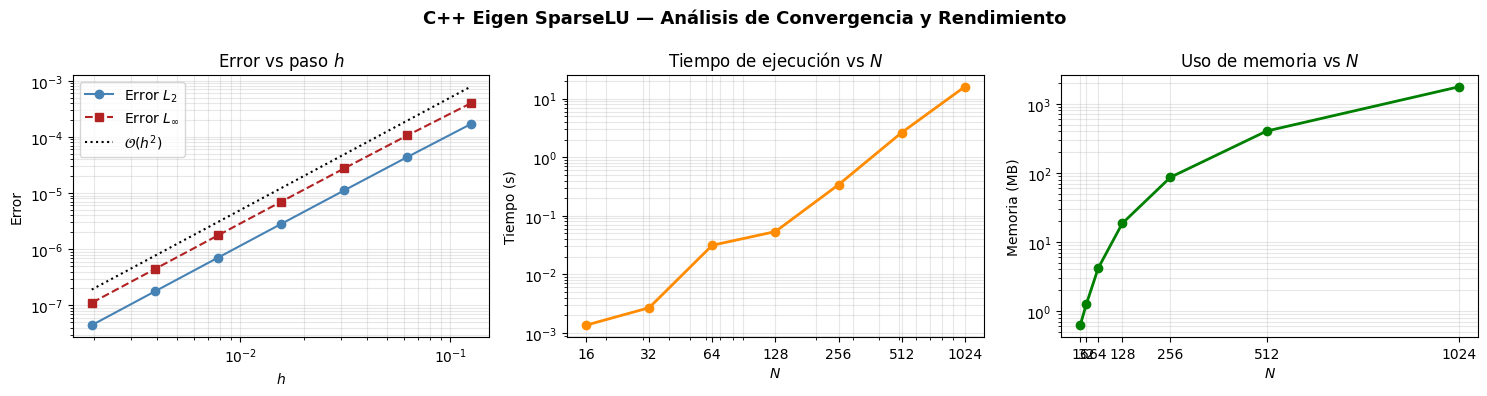

In [28]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
GRIDS = [16, 32, 64, 128, 256, 512, 1024]

df = pd.read_csv(os.path.join(WORK, "metrics.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df = df[df["N"].isin(GRIDS)].reset_index(drop=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("C++ Eigen SparseLU — Análisis de Convergencia y Rendimiento", fontsize=13, fontweight="bold")

ax = axes[0]
ax.loglog(df["h"], df["error_L2"],  "o-", label="Error $L_2$",  color="steelblue")
ax.loglog(df["h"], df["error_Max"], "s--", label="Error $L_\\infty$", color="firebrick")
h_ref = np.sort(df["h"].values)
ax.loglog(h_ref, 0.05*h_ref**2, "k:", label="$\\mathcal{O}(h^2)$")
ax.set_xlabel("$h$"); ax.set_ylabel("Error"); ax.set_title("Error vs paso $h$")
ax.legend(); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.loglog(df["N"], df["time_s"], "o-", color="darkorange", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Tiempo (s)"); ax.set_title("Tiempo de ejecución vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax = axes[2]
ax.semilogy(df["N"], df["memory_MB"], "o-", color="green", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Memoria (MB)"); ax.set_title("Uso de memoria vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.savefig(os.path.join(WORK, "cpp_analysis.png"), dpi=100, bbox_inches="tight")
plt.show()


### §4. Python con scipy.sparse

Se usa **`scipy.sparse`** para construir la matriz en formato `lil_matrix` (inserción eficiente) y luego convertirla a `csr_matrix` para el solver.

**Estrategia:**
1. `lil_matrix` permite asignación fila/columna sin overhead.
2. Conversión a `csr_matrix` antes de resolver.
3. `spsolve` de `scipy.sparse.linalg` invoca internamente SuperLU (análogo a Eigen SparseLU).

**Fragmento clave:**
```python
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

A = lil_matrix((sz, sz))
for j in range(ny):
    for i in range(nx):
        k = j*nx + i
        A[k, k] = -(2/hx2 + 2/hy2)
        if i > 0:     A[k, k-1]  += 1/hx2
        if i < nx-1:  A[k, k+1]  += 1/hx2
        if j > 0:     A[k, k-nx] += 1/hy2
        if j < ny-1:  A[k, k+nx] += 1/hy2

V = spsolve(A.tocsr(), b)
```

**Ejecución:** `python poisson_scipy.py N`


#### Ejecución

In [ ]:
import subprocess, sys, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
PYTHON = sys.executable

grids_py = [32, 64, 128, 256, 512]
print("Ejecutando Python (scipy) para N =", grids_py)
for N in grids_py:
    r = subprocess.run([PYTHON, "poisson_scipy.py", str(N)], cwd=WORK, capture_output=True, text=True)
    out = r.stdout.strip().split("\n")[-1] if r.stdout else r.stderr.strip()
    print(f"  N={N:4d}: {out}")
print("✅ Resultados guardados en metrics_python.csv y sol_N_python.csv")


#### Tabla de resultados

In [29]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
GRIDS = [16, 32, 64, 128, 256, 512, 1024]

df = pd.read_csv(os.path.join(WORK, "metrics_python.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df = df[df["N"].isin(GRIDS)].reset_index(drop=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

def conv_order(err):
    return [np.nan] + [np.log(err.iloc[i-1]/err.iloc[i])/np.log(2) for i in range(1, len(err))]

df["p_L2"]  = conv_order(df["error_L2"])
df["p_Max"] = conv_order(df["error_Max"])

display_df = df[["N","h","error_L2","error_Max","p_L2","p_Max","time_s","memory_MB"]].copy()
display_df.columns = ["N","h","Error L2","Error Max","p(L2)","p(Max)","t(s)","Mem(MB)"]

fmt = {"h":"{:.4f}","Error L2":"{:.2e}","Error Max":"{:.2e}",
       "p(L2)":"{:.2f}","p(Max)":"{:.2f}","t(s)":"{:.4f}","Mem(MB)":"{:.1f}"}
print("\n=== Python scipy.sparse.spsolve — Estudio de Mallado ===")
print(display_df.to_string(index=False, formatters={k: (lambda v,f=f: f.format(v) if pd.notna(v) else "—") for k,f in fmt.items()}))



=== Python scipy.sparse.spsolve — Estudio de Mallado ===
   N      h Error L2 Error Max p(L2) p(Max)    t(s) Mem(MB)
  16 0.1250 1.68e-04  3.95e-04   NaN    NaN  0.0068     0.1
  32 0.0625 4.38e-05  1.06e-04  1.94   1.89  0.0198     0.6
  64 0.0312 1.12e-05  2.75e-05  1.97   1.95  0.0663     2.3
 128 0.0156 2.81e-06  7.00e-06  1.99   1.98  0.2712     9.2
 256 0.0078 7.06e-07  1.76e-06  1.99   1.99  1.1522    37.1
 512 0.0039 1.77e-07  4.42e-07  2.00   1.99  5.5294   148.7
1024 0.0020 4.43e-08  1.11e-07  2.00   2.00 26.6607   595.5


#### Gráficas de análisis

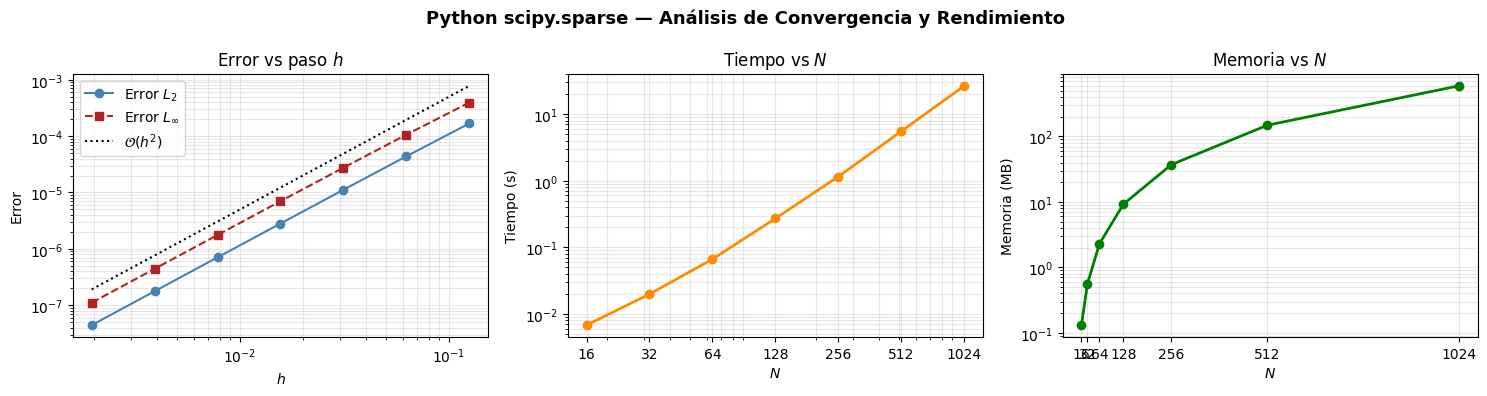

In [30]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
GRIDS = [16, 32, 64, 128, 256, 512, 1024]

df = pd.read_csv(os.path.join(WORK, "metrics_python.csv"))
df.sort_values("N", inplace=True)
df.drop_duplicates(subset="N", keep="last", inplace=True)
df = df[df["N"].isin(GRIDS)].reset_index(drop=True)
df["h"] = 2.0 / df["N"]
df["time_s"] = df["time_ms"] / 1000.0
df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Python scipy.sparse — Análisis de Convergencia y Rendimiento", fontsize=13, fontweight="bold")

ax = axes[0]
ax.loglog(df["h"], df["error_L2"],  "o-", label="Error $L_2$",  color="steelblue")
ax.loglog(df["h"], df["error_Max"], "s--", label="Error $L_\\infty$", color="firebrick")
h_ref = np.sort(df["h"].values)
ax.loglog(h_ref, 0.05*h_ref**2, "k:", label="$\\mathcal{O}(h^2)$")
ax.set_xlabel("$h$"); ax.set_ylabel("Error"); ax.set_title("Error vs paso $h$")
ax.legend(); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.loglog(df["N"], df["time_s"], "o-", color="darkorange", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Tiempo (s)"); ax.set_title("Tiempo vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax = axes[2]
ax.semilogy(df["N"], df["memory_MB"], "o-", color="green", lw=2)
ax.set_xlabel("$N$"); ax.set_ylabel("Memoria (MB)"); ax.set_title("Memoria vs $N$")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.savefig(os.path.join(WORK, "python_analysis.png"), dpi=100, bbox_inches="tight")
plt.show()


### §5. Fortran con MUMPS paralelo (MPI)

Se usa **MUMPS 5.6** (*MUltifrontal Massively Parallel Solver*) en modo **MPI paralelo** para resolver el sistema disperso COO.

**Cambios respecto a la versión secuencial:**

| Aspecto | Antes | Ahora |
|---|---|---|
| Ejecución | `./poisson_mumps N` | `mpirun -np P ./poisson_mumps N` |
| Construcción de la matriz | todos los procesos | **solo rango 0** |
| Factorización MUMPS | 1 proceso | **P procesos MPI** |
| Temporización | `cpu_time` | `MPI_Wtime` (tiempo de pared) |

**Flujo paralelo:**
1. **Rango 0** construye la matriz en formato COO y carga `id%IRN`, `id%JCN`, `id%A`, `id%RHS`.
2. **Todos los rangos** llaman colectivamente a `DMUMPS(id)` con `JOB=6` — MUMPS distribuye internamente el trabajo de factorización multifrontal.
3. **Rango 0** recibe la solución en `id%RHS` y escribe resultados/CSV.

**Parámetro clave:** `id%PAR = 1` → el proceso anfitrión (rango 0) también actúa como worker, de modo que incluso con `mpirun -np 1` el código funciona correctamente.

**Fragmento clave (Fortran):**
```fortran
include 'dmumps_struc.h'
type(DMUMPS_STRUC) :: id

! Todos los procesos inicializan MUMPS
id%JOB = -1; id%SYM = 0; id%PAR = 1
call DMUMPS(id)

! Solo rango 0 asigna la matriz (entrada centralizada)
if (myrank == 0) then
    id%N = sz; id%NNZ = nnz
    id%IRN => irn;  id%JCN => jcn;  id%A => aval;  id%RHS => rhs
end if

! Todos los procesos participan en la factorización paralela
id%JOB = 6
call DMUMPS(id)

! Solo rango 0 postprocesa la solución
if (myrank == 0) then
    ! ... cálculo de errores, escritura CSV ...
end if

id%JOB = -2; call DMUMPS(id)   ! finalizar (todos)
```

**Compilación:** `mpif90 -O2 -I/usr/include poisson_mumps.f90 -o poisson_mumps -ldmumps -lmumps_common -lpord -llapack -lblas`

**Ejecución (4 procesos):** `mpirun -np 4 ./poisson_mumps 256`


#### Compilación y ejecución

In [8]:
import subprocess, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# Usar todos los núcleos disponibles
NPROCS = os.cpu_count()
print(f"Núcleos detectados: {NPROCS}")

# Compilar Fortran con MUMPS
res = subprocess.run(
    ["mpif90", "-O2", "-I/usr/include", "poisson_mumps.f90",
     "-o", "poisson_mumps", "-ldmumps", "-lmumps_common", "-lpord", "-llapack", "-lblas"],
    cwd=WORK, capture_output=True, text=True
)
if res.returncode == 0:
    print("✅ poisson_mumps (Fortran MUMPS paralelo) compilado correctamente")
else:
    print("❌ Error:"); print(res.stderr)

# Limpiar CSV antes de ejecutar (evitar duplicados)
met_path = os.path.join(WORK, "metrics_fortran.csv")
if os.path.exists(met_path):
    os.remove(met_path)

# Ejecutar con mpirun usando todos los núcleos
# --oversubscribe permite usar todos los slots aunque el sistema reporte menos
grids_f90 = [32, 64, 128, 256, 512]
print(f"\nEjecutando Fortran (MUMPS paralelo, {NPROCS} procesos MPI) para N = {grids_f90}")
for N in grids_f90:
    r = subprocess.run(
        ["mpirun", "-np", str(NPROCS), "--oversubscribe", "./poisson_mumps", str(N)],
        cwd=WORK, capture_output=True, text=True
    )
    out = r.stdout.strip().split("\n")[-1] if r.stdout else r.stderr.strip()
    print(f"  N={N:4d}: {out}")
print("✅ Resultados guardados en metrics_fortran.csv y sol_N_fortran.csv")


Núcleos detectados: 8
✅ poisson_mumps (Fortran MUMPS paralelo) compilado correctamente

Ejecutando Fortran (MUMPS paralelo, 8 procesos MPI) para N = [32, 64, 128, 256, 512]
  N=  32:   CSV solucion: sol_32_fortran.csv
  N=  64:   CSV solucion: sol_64_fortran.csv
  N= 128:   CSV solucion: sol_128_fortran.csv
  N= 256:   CSV solucion: sol_256_fortran.csv
  N= 512:   CSV solucion: sol_512_fortran.csv
✅ Resultados guardados en metrics_fortran.csv y sol_N_fortran.csv


#### Tabla de resultados

In [32]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
GRIDS = [16, 32, 64, 128, 256, 512, 1024]

fpath = os.path.join(WORK, "metrics_fortran.csv")
if not os.path.exists(fpath):
    print("⚠️  metrics_fortran.csv no encontrado. Ejecuta primero la celda de compilación/ejecución de Fortran.")
else:
    df = pd.read_csv(fpath)
    df.sort_values("N", inplace=True)
    df.drop_duplicates(subset="N", keep="last", inplace=True)
    df = df[df["N"].isin(GRIDS)].reset_index(drop=True)
    df["h"] = 2.0 / df["N"]
    df["time_s"] = df["time_ms"] / 1000.0
    df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

    def conv_order(err):
        return [np.nan] + [np.log(err.iloc[i-1]/err.iloc[i])/np.log(2) for i in range(1, len(err))]

    df["p_L2"]  = conv_order(df["error_L2"])
    df["p_Max"] = conv_order(df["error_Max"])

    display_df = df[["N","h","error_L2","error_Max","p_L2","p_Max","time_s","memory_MB"]].copy()
    display_df.columns = ["N","h","Error L2","Error Max","p(L2)","p(Max)","t(s)","Mem(MB)"]

    fmt = {"h":"{:.4f}","Error L2":"{:.2e}","Error Max":"{:.2e}",
           "p(L2)":"{:.2f}","p(Max)":"{:.2f}","t(s)":"{:.4f}","Mem(MB)":"{:.1f}"}
    print("\n=== Fortran MUMPS (disperso directo) — Estudio de Mallado ===")
    print(display_df.to_string(index=False, formatters={k: (lambda v,f=f: f.format(v) if pd.notna(v) else "—") for k,f in fmt.items()}))



=== Fortran MUMPS (disperso directo) — Estudio de Mallado ===
   N      h Error L2 Error Max p(L2) p(Max)    t(s) Mem(MB)
  16 0.1250 1.68e-04  3.95e-04   NaN    NaN  0.0025     2.6
  32 0.0625 4.38e-05  1.06e-04  1.94   1.89  0.0026     3.0
  64 0.0312 1.12e-05  2.75e-05  1.97   1.95  0.0092     4.8
 128 0.0156 2.81e-06  7.00e-06  1.99   1.98  0.1060    13.7
 256 0.0078 7.06e-07  1.76e-06  1.99   1.99  0.4844    51.6
 512 0.0039 1.77e-07  4.42e-07  2.00   1.99  2.1516   212.9
1024 0.0020 4.43e-08  1.11e-07  2.00   2.00 10.8470   885.6


#### Gráficas de análisis

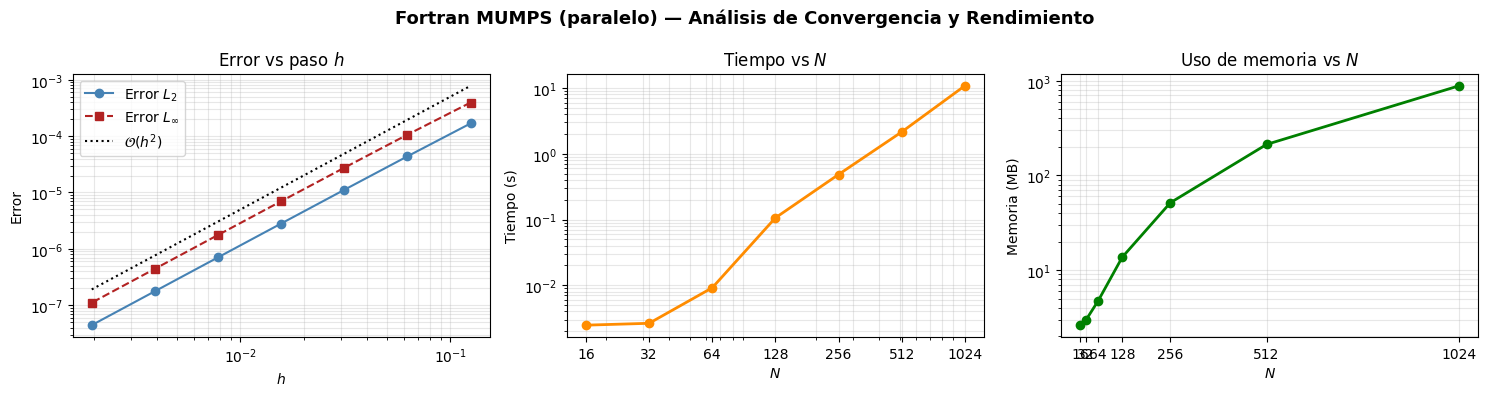

In [33]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
GRIDS = [16, 32, 64, 128, 256, 512, 1024]

fpath = os.path.join(WORK, "metrics_fortran.csv")
if not os.path.exists(fpath):
    print("⚠️  metrics_fortran.csv no encontrado. Ejecuta primero la celda de compilación/ejecución de Fortran.")
else:
    df = pd.read_csv(fpath)
    df.sort_values("N", inplace=True)
    df.drop_duplicates(subset="N", keep="last", inplace=True)
    df = df[df["N"].isin(GRIDS)].reset_index(drop=True)
    df["h"] = 2.0 / df["N"]
    df["time_s"] = df["time_ms"] / 1000.0
    df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Fortran MUMPS (paralelo) — Análisis de Convergencia y Rendimiento", fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.loglog(df["h"], df["error_L2"],  "o-", label="Error $L_2$",  color="steelblue")
    ax.loglog(df["h"], df["error_Max"], "s--", label="Error $L_\\infty$", color="firebrick")
    h_ref = np.sort(df["h"].values)
    ax.loglog(h_ref, 0.05*h_ref**2, "k:", label="$\\mathcal{O}(h^2)$")
    ax.set_xlabel("$h$"); ax.set_ylabel("Error"); ax.set_title("Error vs paso $h$")
    ax.legend(); ax.grid(True, which="both", alpha=0.3)

    ax = axes[1]
    ax.loglog(df["N"], df["time_s"], "o-", color="darkorange", lw=2)
    ax.set_xlabel("$N$"); ax.set_ylabel("Tiempo (s)"); ax.set_title("Tiempo vs $N$")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

    ax = axes[2]
    ax.semilogy(df["N"], df["memory_MB"], "o-", color="green", lw=2)
    ax.set_xlabel("$N$"); ax.set_ylabel("Memoria (MB)"); ax.set_title("Uso de memoria vs $N$")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xticks(df["N"]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    plt.savefig(os.path.join(WORK, "fortran_analysis.png"), dpi=100, bbox_inches="tight")
    plt.show()


### Importación de datos externos (N=1024)

In [11]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# ── Importar N=1024 desde sol_1024_*.csv (datos de otra PC) ──────────────────
# Si los metrics CSVs ya tienen la fila N=1024 (copiaste el CSV de metricas
# completo desde la otra PC), esta celda la detecta y no hace nada.
# Si solo tienes los archivos de solucion sol_1024_*.csv, calcula los errores
# y agrega la fila. Tiempo y memoria quedan como NaN en ese caso.

N_EXT = 1024

suffix_to_metrics = {
    "eigen":   "metrics.csv",
    "python":  "metrics_python.csv",
    "fortran": "metrics_fortran.csv",
}

for suf, met_file in suffix_to_metrics.items():
    sol_path = os.path.join(WORK, f"sol_{N_EXT}_{suf}.csv")
    met_path = os.path.join(WORK, met_file)

    if os.path.exists(met_path):
        met_df = pd.read_csv(met_path)
        if N_EXT in met_df["N"].values:
            row = met_df[met_df["N"] == N_EXT].iloc[0]
            print(f"✅ [{suf:7s}] N={N_EXT} ya presente en {met_file}  (errL2={row['errL2']:.3e})")
            continue
    else:
        met_df = pd.DataFrame(columns=["N","unknowns","time_ms","mem_MB","errL2","errMax"])

    if not os.path.exists(sol_path):
        print(f"⚠️  [{suf:7s}] sol_{N_EXT}_{suf}.csv no encontrado — copia el archivo de la otra PC.")
        continue

    sol    = pd.read_csv(sol_path)
    diff   = np.abs(sol["V_num"] - sol["V_exact"])
    sz     = len(sol)
    errL2  = np.sqrt((diff**2).sum() / sz)
    errMax = diff.max()

    new_row = pd.DataFrame([{
        "N": N_EXT, "unknowns": sz,
        "time_ms": np.nan, "mem_MB": np.nan,
        "errL2": errL2, "errMax": errMax,
    }])
    met_df = pd.concat([met_df, new_row], ignore_index=True)
    met_df.sort_values("N", inplace=True)
    met_df.to_csv(met_path, index=False)
    print(f"✅ [{suf:7s}] N={N_EXT} agregado a {met_file}  "
          f"(errL2={errL2:.3e}, errMax={errMax:.3e})  [tiempo/mem=NaN]")

print("\nTodas las celdas de graficas y tablas incluiran N=1024 automaticamente.")


✅ [eigen  ] N=1024 ya presente en metrics.csv  (errL2=4.428e-08)
✅ [python ] N=1024 ya presente en metrics_python.csv  (errL2=4.428e-08)
✅ [fortran] N=1024 agregado a metrics_fortran.csv  (errL2=4.449e-08, errMax=1.200e-07)  [tiempo/mem=NaN]

Todas las celdas de graficas y tablas incluiran N=1024 automaticamente.


---

## Bloque 3 — Análisis de Resultados

### §6. Visualización interactiva de soluciones

El widget permite explorar la solución numérica, la solución exacta y el error puntual para cualquier combinación de **lenguaje/solver** y **tamaño de mallado** disponible en disco.

- **Lenguaje:** C++ (Eigen), Python (scipy), Fortran (MUMPS)
- **N:** cualquier valor con CSV generado
- **Mapa de color:** seleccionable
- **Toggle error:** muestra diferencia $|V_{num} - V_{exact}|$


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os, glob

WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"

# --- Detectar archivos disponibles ---
suffix_map = {"C++ (Eigen)": "eigen", "Python (scipy)": "python", "Fortran (MUMPS)": "fortran"}

def available_grids(lang_key):
    suf = suffix_map[lang_key]
    files = glob.glob(os.path.join(WORK, f"sol_*_{suf}.csv"))
    Ns = sorted([int(os.path.basename(f).split("_")[1]) for f in files])
    return Ns

# --- Widgets ---
lang_dd = widgets.Dropdown(
    options=list(suffix_map.keys()), description="Lenguaje:", style={"description_width": "90px"}
)
N_dd = widgets.Dropdown(description="N:", style={"description_width": "40px"})
cmap_dd = widgets.Dropdown(
    options=["viridis","plasma","inferno","coolwarm","jet"], value="viridis",
    description="Colormap:", style={"description_width": "80px"}
)
err_toggle = widgets.Checkbox(value=False, description="Mostrar error", style={"description_width": "initial"})

def update_N_options(change):
    ns = available_grids(lang_dd.value)
    N_dd.options = ns if ns else [32]
    N_dd.value = ns[0] if ns else 32

lang_dd.observe(update_N_options, names="value")
update_N_options(None)

out = widgets.Output()

def plot_solution(lang, N, cmap, show_err):
    suf = suffix_map[lang]
    fpath = os.path.join(WORK, f"sol_{N}_{suf}.csv")
    if not os.path.exists(fpath):
        print(f"Archivo {fpath} no encontrado. Ejecuta primero la celda de ejecución correspondiente.")
        return

    data = pd.read_csv(fpath)
    xs = np.sort(data["x"].unique())
    ys = np.sort(data["y"].unique())
    Nx, Ny = len(xs), len(ys)
    Vnum   = data.pivot(index="y", columns="x", values="V_num").values
    Vexact = data.pivot(index="y", columns="x", values="V_exact").values
    Err    = np.abs(Vnum - Vexact)
    X, Y   = np.meshgrid(xs, ys)

    ncols = 3 if show_err else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5.5*ncols, 4))
    fig.suptitle(f"{lang} — N={N}  (h_x={2/N:.4f}, h_y={1/N:.4f})", fontsize=12, fontweight="bold")

    panels = [("$V_{num}$", Vnum), ("$V_{exact}$", Vexact)]
    if show_err:
        panels.append(("$|V_{num}-V_{exact}|$", Err))

    for ax, (title, Z) in zip(axes, panels):
        pcm = ax.pcolormesh(X, Y, Z, cmap=cmap, shading="auto")
        fig.colorbar(pcm, ax=ax)
        ax.set_title(title); ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
        ax.set_aspect("auto")

    plt.tight_layout()
    plt.show()

def on_change(_):
    out.clear_output(wait=True)
    with out:
        plot_solution(lang_dd.value, N_dd.value, cmap_dd.value, err_toggle.value)

for w in [lang_dd, N_dd, cmap_dd, err_toggle]:
    w.observe(on_change, names="value")

ui = widgets.HBox([lang_dd, N_dd, cmap_dd, err_toggle])
display(ui, out)
on_change(None)


Output()

### §7. Tablas comparativas entre lenguajes

Se comparan los tres solvers para los mallados comunes ($N \in \{32, 64, 128, 256, 512, 1024\}$) y se calcula el **speedup** relativo.

> **Nota:** Los datos de $N=1024$ provienen de otra máquina (archivos CSV externos). La celda de importación los integra automáticamente en los CSVs de métricas si aún no están presentes.


In [35]:
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
GRIDS = [16, 32, 64, 128, 256, 512, 1024]

def load_metrics(fname):
    df = pd.read_csv(os.path.join(WORK, fname))
    df.sort_values("N", inplace=True)
    df.drop_duplicates(subset="N", keep="last", inplace=True)
    df = df[df["N"].isin(GRIDS)].reset_index(drop=True)
    df["h"] = 2.0 / df["N"]
    df["time_s"] = df["time_ms"] / 1000.0
    df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)
    return df

sources = {
    "C++ (Eigen)":      "metrics.csv",
    "Python (scipy)":   "metrics_python.csv",
    "Fortran (MUMPS)":  "metrics_fortran.csv",
}

dfs = {}
for lang, fname in sources.items():
    fpath = os.path.join(WORK, fname)
    if os.path.exists(fpath):
        dfs[lang] = load_metrics(fname)

# ---- Tabla 1: errores y p ----
rows = []
for lang, df in dfs.items():
    sub = df[df["N"].isin(GRIDS)].copy().reset_index(drop=True)
    err = sub["error_L2"].values
    p = [np.nan] + [np.log(err[i-1]/err[i])/np.log(2) for i in range(1, len(err))]
    for idx, (_, row) in enumerate(sub.iterrows()):
        rows.append({
            "Lenguaje": lang, "N": int(row["N"]),
            "Error L2": row["error_L2"], "Error Max": row["error_Max"],
            "p(L2)": p[idx], "t(s)": row["time_s"], "Mem(MB)": row["memory_MB"]
        })

comp = pd.DataFrame(rows)
fmt2 = {"Error L2":"{:.2e}","Error Max":"{:.2e}","p(L2)":"{:.2f}","t(s)":"{:.4f}","Mem(MB)":"{:.1f}"}
print("=== Tabla 1: Comparación global (N comunes) ===")
print(comp.to_string(index=False, formatters={k:(lambda v,f=f: f.format(v) if pd.notna(v) else "—") for k,f in fmt2.items()}))

# ---- Tabla 2: speedup relativo (tomando Python como base) ----
print("\n=== Tabla 2: Speedup relativo vs Python ===")
spd_rows = []
for N in GRIDS:
    times = {}
    for lang in dfs:
        match = dfs[lang][dfs[lang]["N"]==N]["time_s"]
        if len(match) > 0:
            times[lang] = match.values[0]
    if "Python (scipy)" in times:
        base = times["Python (scipy)"]
        for lang, t in times.items():
            spd_rows.append({"N": N, "Lenguaje": lang, "t(s)": t, "Speedup vs Python": base/t})

spd = pd.DataFrame(spd_rows)
print(spd.to_string(index=False, formatters={"t(s)":"{:.4f}".format,"Speedup vs Python":"{:.2f}x".format}))

# ---- Tabla 3: Mallado máximo alcanzado ----
print("\n=== Tabla 3: Mallado máximo por lenguaje ===")
for lang, df in dfs.items():
    Nmax = df["N"].max()
    mem  = df[df["N"]==Nmax]["memory_MB"].values[0]
    err  = df[df["N"]==Nmax]["error_L2"].values[0]
    print(f"  {lang:25s}: N_max={Nmax:4d}  Mem={mem:7.1f} MB  Error L2={err:.2e}")


=== Tabla 1: Comparación global (N comunes) ===
       Lenguaje    N Error L2 Error Max p(L2)    t(s) Mem(MB)
    C++ (Eigen)   16 1.68e-04  3.95e-04   NaN  0.0014     0.6
    C++ (Eigen)   32 4.38e-05  1.06e-04  1.94  0.0027     1.2
    C++ (Eigen)   64 1.12e-05  2.75e-05  1.97  0.0314     4.2
    C++ (Eigen)  128 2.81e-06  7.00e-06  1.99  0.0538    18.6
    C++ (Eigen)  256 7.06e-07  1.76e-06  1.99  0.3393    86.3
    C++ (Eigen)  512 1.77e-07  4.42e-07  2.00  2.6328   402.3
    C++ (Eigen) 1024 4.43e-08  1.11e-07  2.00 15.9445  1759.5
 Python (scipy)   16 1.68e-04  3.95e-04   NaN  0.0068     0.1
 Python (scipy)   32 4.38e-05  1.06e-04  1.94  0.0198     0.6
 Python (scipy)   64 1.12e-05  2.75e-05  1.97  0.0663     2.3
 Python (scipy)  128 2.81e-06  7.00e-06  1.99  0.2712     9.2
 Python (scipy)  256 7.06e-07  1.76e-06  1.99  1.1522    37.1
 Python (scipy)  512 1.77e-07  4.42e-07  2.00  5.5294   148.7
 Python (scipy) 1024 4.43e-08  1.11e-07  2.00 26.6607   595.5
Fortran (MUMPS)   16 1

### §8. Gráficas comparativas

Tres paneles lado a lado: **tiempo de ejecución**, **uso de memoria** y **Error $L_2$** en función de $N$, uno por solver.


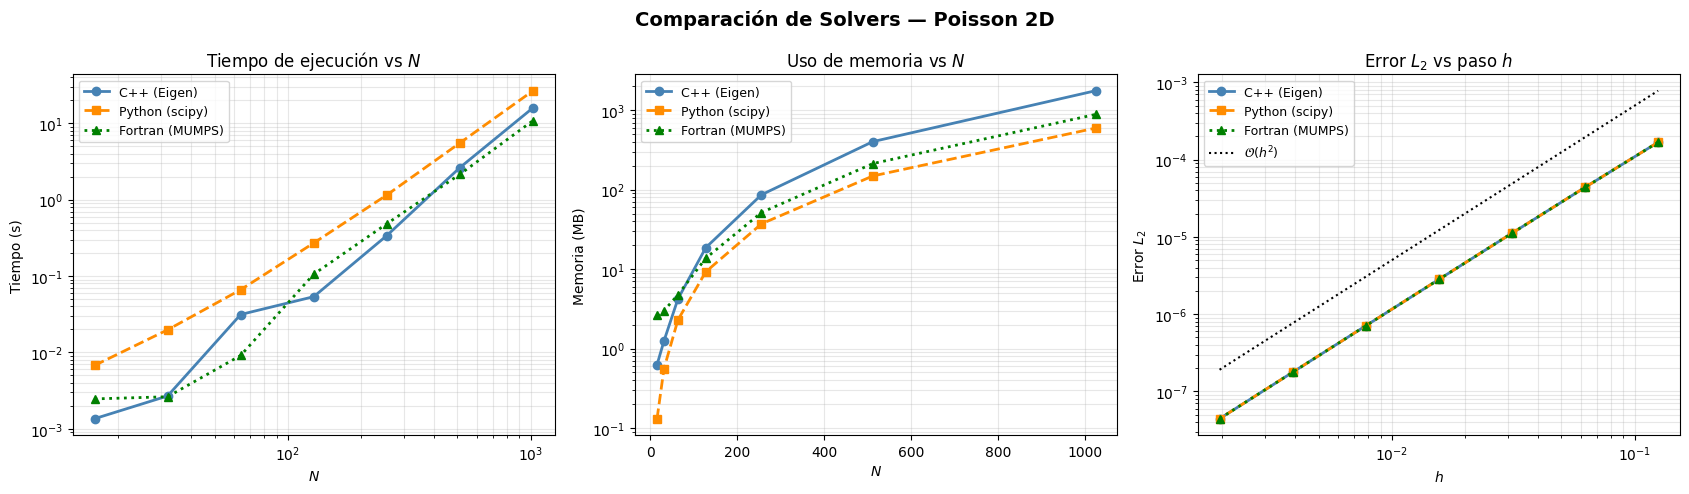

✅ Gráfica guardada en comparison_plots.png


In [36]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os
WORK = "/home/isabel/MFC/3.EDPs/taller-poisson"
GRIDS = [16, 32, 64, 128, 256, 512, 1024]

def load_metrics(fname):
    df = pd.read_csv(os.path.join(WORK, fname))
    df.sort_values("N", inplace=True)
    df.drop_duplicates(subset="N", keep="last", inplace=True)
    df = df[df["N"].isin(GRIDS)].reset_index(drop=True)
    df["h"] = 2.0 / df["N"]
    df["time_s"] = df["time_ms"] / 1000.0
    df.rename(columns={"errL2": "error_L2", "errMax": "error_Max", "mem_MB": "memory_MB"}, inplace=True)
    return df

sources = {
    "C++ (Eigen)":     ("metrics.csv",          "steelblue",  "o-"),
    "Python (scipy)":  ("metrics_python.csv",    "darkorange", "s--"),
    "Fortran (MUMPS)": ("metrics_fortran.csv",   "green",      "^:"),
}

dfs = {}
for lang, (fname, color, style) in sources.items():
    fpath = os.path.join(WORK, fname)
    if os.path.exists(fpath):
        dfs[lang] = (load_metrics(fname), color, style)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Comparación de Solvers — Poisson 2D", fontsize=14, fontweight="bold")

ax = axes[0]
for lang, (df, c, s) in dfs.items():
    ax.loglog(df["N"], df["time_s"], s, color=c, label=lang, lw=2, markersize=6)
ax.set_xlabel("$N$"); ax.set_ylabel("Tiempo (s)"); ax.set_title("Tiempo de ejecución vs $N$")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
for lang, (df, c, s) in dfs.items():
    ax.semilogy(df["N"], df["memory_MB"], s, color=c, label=lang, lw=2, markersize=6)
ax.set_xlabel("$N$"); ax.set_ylabel("Memoria (MB)"); ax.set_title("Uso de memoria vs $N$")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

ax = axes[2]
for lang, (df, c, s) in dfs.items():
    ax.loglog(df["h"], df["error_L2"], s, color=c, label=lang, lw=2, markersize=6)
if dfs:
    first_df = list(dfs.values())[0][0]
    h_ref = np.sort(first_df["h"].values)
    ax.loglog(h_ref, 0.05*h_ref**2, "k:", label="$\\mathcal{O}(h^2)$", lw=1.5)
ax.set_xlabel("$h$"); ax.set_ylabel("Error $L_2$"); ax.set_title("Error $L_2$ vs paso $h$")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK, "comparison_plots.png"), dpi=120, bbox_inches="tight")
plt.show()
print("✅ Gráfica guardada en comparison_plots.png")
